In [1]:
#Load and Prepare the Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score


In [2]:
# Load Wine dataset
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target  # true class labels (0,1,2)
class_names = wine.target_names

print("Dataset shape:", X.shape)
print("\nFeatures:", list(X.columns))

# Basic exploration
print("\nFirst 5 rows:")
display(X.head())

print("\nClass distribution:")
class_counts = pd.Series(y).value_counts().sort_index()
for i, c in class_counts.items():
    print(f"Class {i} ({class_names[i]}): {c} samples")

# Standardize (z-score normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Dataset shape: (178, 13)

Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Class distribution:
Class 0 (class_0): 59 samples
Class 1 (class_1): 71 samples
Class 2 (class_2): 48 samples


In [3]:
#Implement K-Means Clustering (k=3)

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print("K-Means Results")
print("Silhouette Score:", round(kmeans_sil, 4))
print("ARI:", round(kmeans_ari, 4))

K-Means Results
Silhouette Score: 0.2849
ARI: 0.8975


In [4]:
from sklearn.metrics import pairwise_distances, silhouette_score, adjusted_rand_score

def kmedoids_pam(X, k=3, max_iter=200, random_state=42):
    rng = np.random.RandomState(random_state)

    # Distance matrix
    D = pairwise_distances(X, metric="euclidean")
    n = X.shape[0]

    # Pick initial medoids randomly
    medoids = rng.choice(n, size=k, replace=False)

    for _ in range(max_iter):
        # Assign each point to closest medoid
        labels = np.argmin(D[:, medoids], axis=1)

        new_medoids = medoids.copy()
        for cluster_id in range(k):
            cluster_points = np.where(labels == cluster_id)[0]

            # If a cluster becomes empty, re-pick a random medoid
            if len(cluster_points) == 0:
                new_medoids[cluster_id] = rng.choice(n)
                continue

            # Choose point in cluster minimizing total distance to others
            cluster_D = D[np.ix_(cluster_points, cluster_points)]
            costs = cluster_D.sum(axis=1)
            best_point = cluster_points[np.argmin(costs)]
            new_medoids[cluster_id] = best_point

        if np.array_equal(new_medoids, medoids):
            break
        medoids = new_medoids

    labels = np.argmin(D[:, medoids], axis=1)
    return medoids, labels

# Run K-Medoids (k=3)
medoid_indices, kmedoids_labels = kmedoids_pam(X_scaled, k=3, random_state=42)

# Metrics (same as rubric)
kmedoids_sil = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

print("K-Medoids (Manual PAM) Results")
print("Silhouette Score:", round(kmedoids_sil, 4))
print("ARI:", round(kmedoids_ari, 4))

K-Medoids (Manual PAM) Results
Silhouette Score: 0.1548
ARI: 0.3413


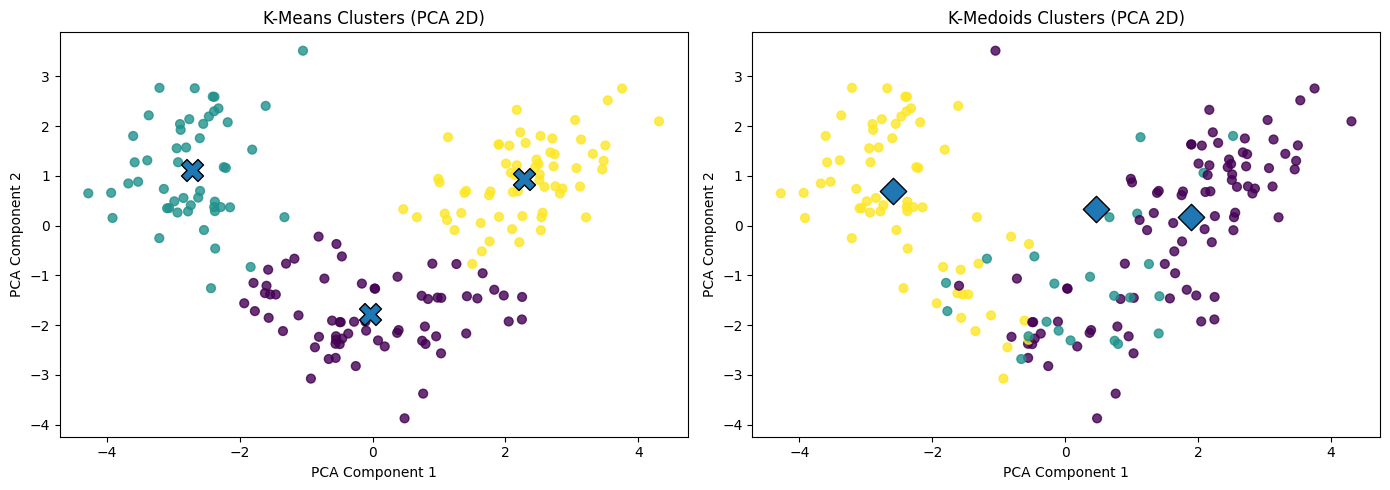

In [5]:
# PCA to 2D for plotting
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# K-Means centroids -> PCA space
kmeans_centroids_scaled = kmeans.cluster_centers_
kmeans_centroids_pca = pca.transform(kmeans_centroids_scaled)

# K-Medoids medoids -> PCA space (manual PAM uses indices)
medoid_points_scaled = X_scaled[medoid_indices]
medoid_points_pca = pca.transform(medoid_points_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means plot
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, s=40, alpha=0.8)
axes[0].scatter(
    kmeans_centroids_pca[:, 0], kmeans_centroids_pca[:, 1],
    marker="X", s=250, edgecolors="black"
)
axes[0].set_title("K-Means Clusters (PCA 2D)")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")

# K-Medoids plot
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmedoids_labels, s=40, alpha=0.8)
axes[1].scatter(
    medoid_points_pca[:, 0], medoid_points_pca[:, 1],
    marker="D", s=180, edgecolors="black"
)
axes[1].set_title("K-Medoids Clusters (PCA 2D)")
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")

plt.tight_layout()
plt.show()

K-Medoids Results (Manual PAM)
Silhouette Score = 0.1548
ARI = 0.3413
A Silhouette Score of 0.1548 is relatively low, which means the clusters are not very well separated and there is some overlap between groups.
An ARI of 0.3413 means the clustering matches the true Wine classes somewhat, but not perfectly.

Which algorithm produced better-defined clusters?

Based on the plots, K-Means produced better-defined clusters. The K-Means clusters look more separated, while the K-Medoids clusters show more mixing (especially around the middle/right region).

(If your K-Means Silhouette Score is higher than 0.1548 and ARI is higher than 0.3413, that would also confirm that K-Means performed better.)

What differences do you observe in cluster shapes or positioning?

K-Means forms clusters around an “average center” (centroid), so groups often look more centered and clean in the PCA plot.
K-Medoids uses real data points as centers (medoids). Because of that, clusters can look more spread out and may overlap more in the 2D PCA view.
Since this is a PCA 2D plot, some separation that exists in higher dimensions may not fully appear in 2D.

When is K-Means vs K-Medoids preferable?

Prefer K-Means when data is fairly clean and clusters are reasonably separated. It is also faster and works well in many cases.
Prefer K-Medoids when there may be outliers or noisy points, because it is usually less affected by extreme values (since it uses actual points as centers).
Note: I used a manual PAM implementation for K-Medoids in Colab because scikit-learn-extra was not compatible with NumPy 2.x in this environment.